In [1]:
# NETFLIX EDA — FULL CODE FOR ALL 30 QUESTIONS
# (matches netflix_eda_questions_25plus.csv)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
 # DATA LOADING (Q1-Q3)

In [4]:
# Q1: Load and display first 5 rows
df = pd.read_csv("netflix.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,A City,Alfonso Cuaron,"Emma Kim, Chloe Smith, Noah Nakamura",Mexico,"February 19, 2023",1998,G,124 min,Dramas,A story exploring ambition set in Mexico.
1,s2,Movie,The Storm,NaN,"Diego Garcia, Yuki Patel, Wei Sharma, Ravi Kim...",Canada,"April 25, 2017",2015,R,113 min,Comedies,A story exploring friendship set in Canada.
2,s3,Movie,The City,Rajkumar Hirani,"Liam Smith, Carlos Silva, Priya Rossi, Wei Joh...",Nigeria,"April 23, 2024",2006,PG-13,78 min,Documentaries,A story exploring friendship set in Nigeria.
3,s4,Movie,A Mirror,NaN,"John Chen, Sara Garcia, Noah Khan, Chloe Johnson",Germany,"February 20, 2025",2006,PG,151 min,Children & Family Movies,A story exploring family bonds set in Germany.
4,s5,Movie,A Mirror,Zoya Akhtar,"Noah Chen, Anna Sharma, Emma Sharma",Mexico,"July 09, 2023",2018,PG-13,78 min,Independent Movies,A story exploring family bonds set in Mexico.


In [5]:
# Q2: Dataset structure
print(df.shape)
print(df.info())

(1205, 12)
<class 'pandas.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       1205 non-null   str  
 1   type          1205 non-null   str  
 2   title         1205 non-null   str  
 3   director      720 non-null    str  
 4   cast          1205 non-null   str  
 5   country       1109 non-null   str  
 6   date_added    1199 non-null   str  
 7   release_year  1205 non-null   int64
 8   rating        1193 non-null   str  
 9   duration      1205 non-null   str  
 10  listed_in     1205 non-null   str  
 11  description   1205 non-null   str  
dtypes: int64(1), str(11)
memory usage: 113.1 KB
None


In [6]:
# Q3: Summary statistics
df.describe()

,release_year
count,1205.000000
mean,2012.196680
std,8.494399
min,1998.000000
25%,2005.000000
50%,2013.000000
75%,2020.000000
max,2026.000000


In [7]:
# DATA CLEANING (Q4-Q9)

In [8]:
# Q4: Missing values in every column
print(df.isnull().sum())

show_id           0
type              0
title             0
director        485
cast              0
country          96
date_added        6
release_year      0
rating           12
duration          0
listed_in         0
description       0
dtype: int64


In [9]:
# Q5: Fill missing director
df['director'] = df['director'].fillna('Not Specified')

In [10]:
# Q6: Fill missing country
df['country'] = df['country'].fillna('Not Specified')

In [11]:
# Q7: Check and remove duplicates
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicates: 5


In [12]:
# Q8: Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [13]:
# Q9: Extract year_added and month_added
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

In [14]:
# NUMPY OPERATIONS (Q10-Q12)

In [15]:
# Q10: Min, max, mean of release_year using NumPy
years = df['release_year'].to_numpy()
print("Min:", np.min(years))
print("Max:", np.max(years))
print("Mean:", np.mean(years))

Min: 1998
Max: 2026
Mean: 2012.225


In [16]:
# Q11: Extract numeric duration, calculate std dev
df['duration_value'] = df['duration'].str.extract(r'(\d+)').astype(float)
print("Duration Std Dev:", np.std(df['duration_value'].dropna().to_numpy()))

Duration Std Dev: 61.47215141269708


In [17]:
# Q12: Distinct types with counts using np.unique
values, counts = np.unique(df['type'], return_counts=True)
print(dict(zip(values, counts)))

{'Movie': np.int64(847), 'TV Show': np.int64(353)}


In [18]:
# EXPLORATION (Q13-Q18)

In [19]:
# Q13: Total Movies vs TV Shows
print(df['type'].value_counts())

type
Movie      847
TV Show    353
Name: count, dtype: int64


In [20]:
# Q14: Top 10 countries
top_countries = df[df['country'] != 'Not Specified']['country'].value_counts().head(10)
print(top_countries)

country
Nigeria           90
United Kingdom    86
India             82
Germany           78
South Korea       77
United States     76
Egypt             75
Japan             73
Italy             71
Spain             70
Name: count, dtype: int64


In [21]:
# Q15: Titles released each year, sorted by year
print(df['release_year'].value_counts().sort_index())

release_year
1998    43
1999    51
2000    46
2001    35
2002    42
2003    30
2004    35
2005    41
2006    29
2007    40
2008    47
2009    40
2010    39
2011    40
2012    40
2013    53
2014    39
2015    44
2016    48
2017    40
2018    34
2019    29
2020    41
2021    44
2022    53
2023    45
2024    40
2025    50
2026    42
Name: count, dtype: int64


In [22]:
# Q16: Top 10 genres
genre_series = df['listed_in'].str.split(', ').explode()
top_genres = genre_series.value_counts().head(10)
print(top_genres)

listed_in
Documentaries               181
Thrillers                   181
Independent Movies          176
Romantic Movies             174
Action & Adventure          170
Comedies                    168
Dramas                      164
Sci-Fi & Fantasy            161
Children & Family Movies    157
Horror Movies               142
Name: count, dtype: int64


In [23]:
# Q17: Director with most titles
top_director = df[df['director'] != 'Not Specified']['director'].value_counts().head(1)
print(top_director)

director
Sofia Coppola    89
Name: count, dtype: int64


In [24]:
# Q18: Average release_year by rating
print(df.groupby('rating')['release_year'].mean().round(1))

rating
G        2012.7
NC-17    2012.3
PG       2012.8
PG-13    2012.0
R        2011.5
TV-14    2011.8
TV-G     2013.7
TV-MA    2010.7
TV-PG    2011.7
TV-Y     2011.8
TV-Y7    2014.1
Name: release_year, dtype: float64


In [25]:
# VISUALIZATION - DISTRIBUTION (Q19 - Q25)

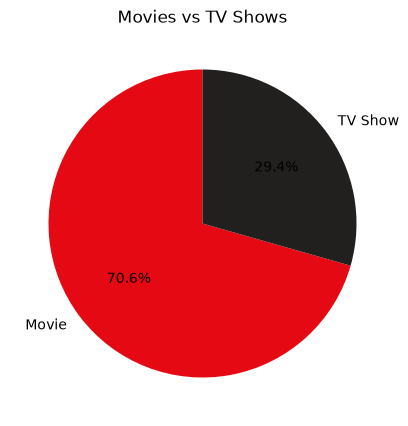

In [26]:
# Q19: Pie chart - Movies vs TV Shows
type_counts = df['type'].value_counts()
plt.figure(figsize=(5, 5))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
        colors=['#E50914', '#221F1F'], startangle=90)
plt.title("Movies vs TV Shows")
plt.show()

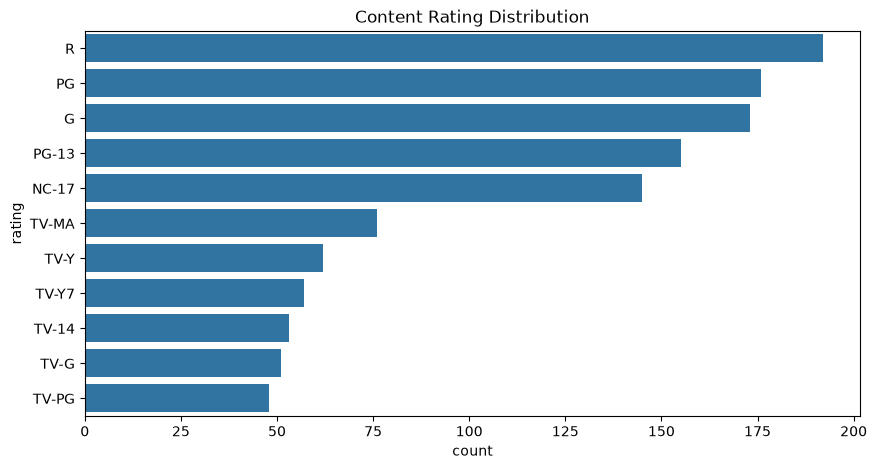

In [27]:
# Q20: Count plot of ratings
plt.figure(figsize=(10, 5))
sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index)
plt.title("Content Rating Distribution")
plt.show()

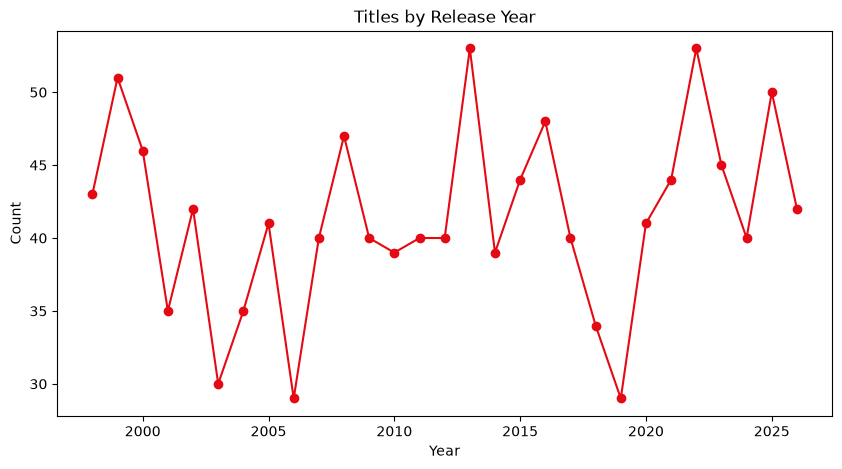

In [28]:
# Q21: Line chart - titles by release year
plt.figure(figsize=(10, 5))
df['release_year'].value_counts().sort_index().plot(kind='line', marker='o', color='#E50914')
plt.title("Titles by Release Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()


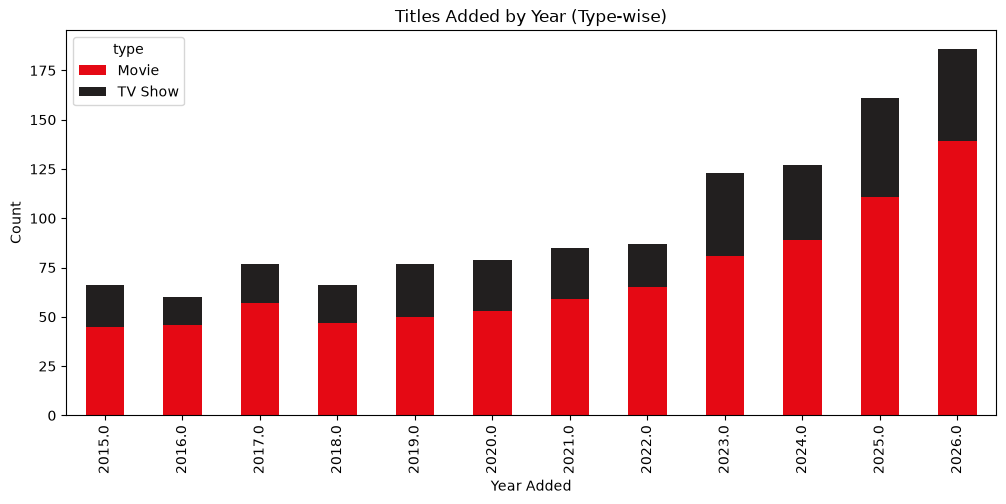

In [29]:
# Q22: Stacked bar chart - titles added by year, split by type
yearly_type = df.dropna(subset=['year_added']).groupby(['year_added', 'type']).size().unstack(fill_value=0)
yearly_type.plot(kind='bar', stacked=True, figsize=(12, 5), color=['#E50914', '#221F1F'])
plt.title("Titles Added by Year (Type-wise)")
plt.xlabel("Year Added")
plt.ylabel("Count")
plt.show()

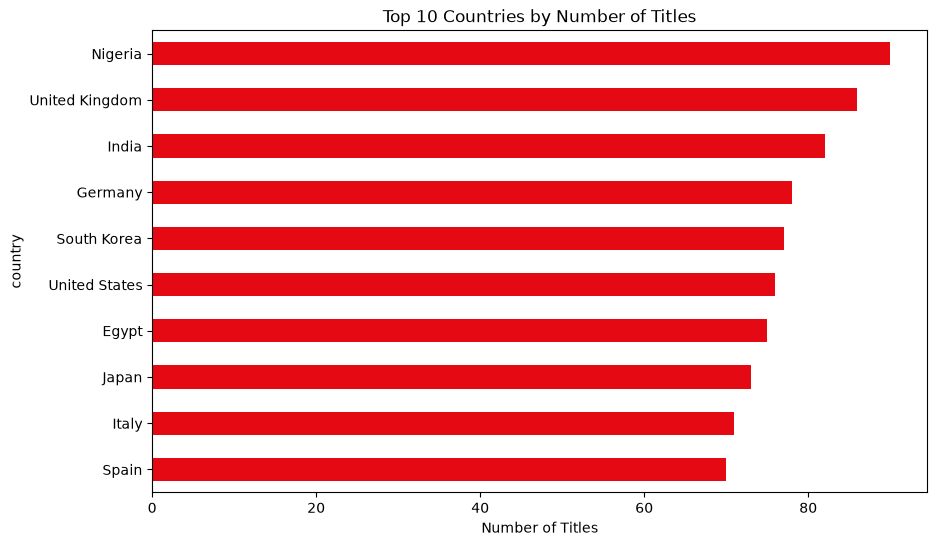

In [30]:
# Q23: Horizontal bar chart - top 10 countries
plt.figure(figsize=(10, 6))
top_countries.plot(kind='barh', color='#E50914')
plt.title("Top 10 Countries by Number of Titles")
plt.xlabel("Number of Titles")
plt.gca().invert_yaxis()
plt.show()

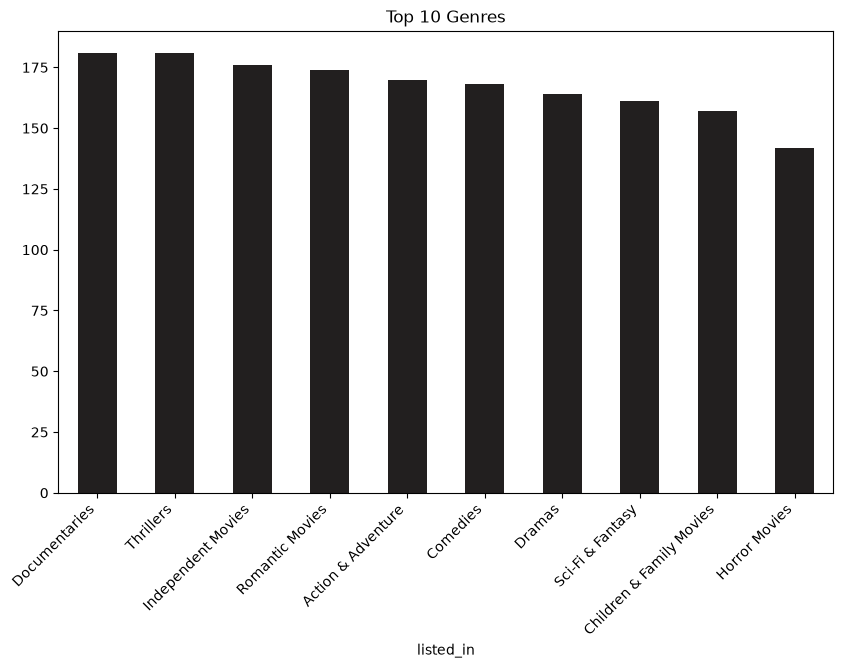

In [31]:
# Q24: Bar chart - top 10 genres
plt.figure(figsize=(10, 6))
top_genres.plot(kind='bar', color='#221F1F')
plt.title("Top 10 Genres")
plt.xticks(rotation=45, ha='right')
plt.show()

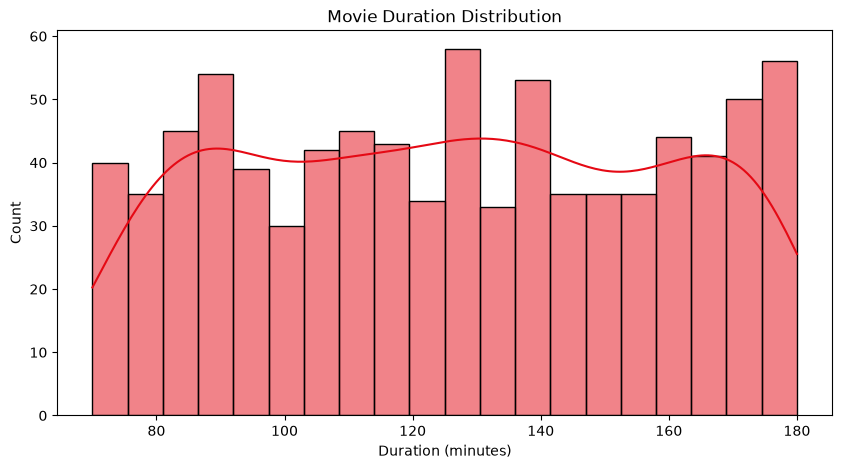

In [32]:
# Q25: Histogram with KDE for movie duration
movie_durations = df[df['type'] == 'Movie']['duration_value']
plt.figure(figsize=(10, 5))
sns.histplot(movie_durations, bins=20, kde=True, color='#E50914')
plt.title("Movie Duration Distribution")
plt.xlabel("Duration (minutes)")
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_10012\1822378844.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='type', y='release_year', data=df, palette=['red','black'])


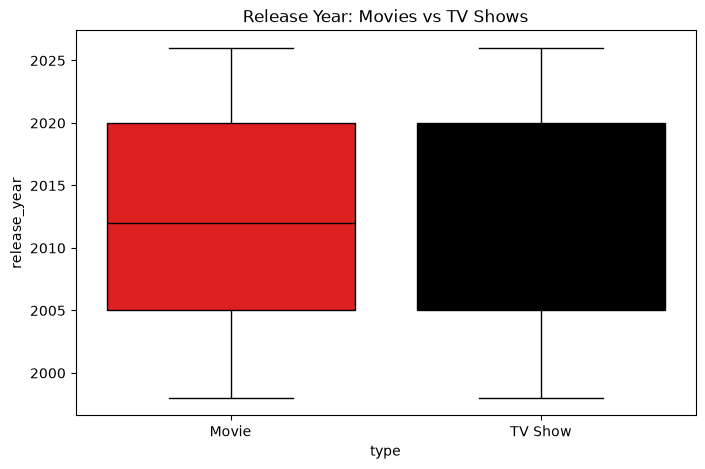

In [33]:
# Q26: Box plot - release_year by type
plt.figure(figsize=(8, 5))
sns.boxplot(x='type', y='release_year', data=df, palette=['red','black'])
plt.title("Release Year: Movies vs TV Shows")
plt.show()

In [34]:
# VISUALIZATION - CORRELATION (Q27)

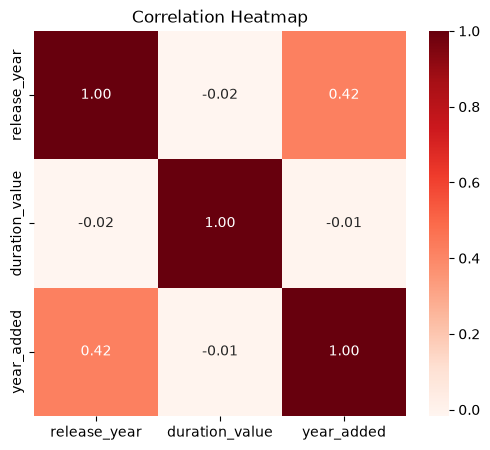

In [35]:
# Q27: Correlation heatmap
numeric_df = df[['release_year', 'duration_value', 'year_added']].dropna()
plt.figure(figsize=(6, 5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='Reds', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

In [36]:
# VISUALIZATION - CUSTOMIZATION (Q28, Q29)

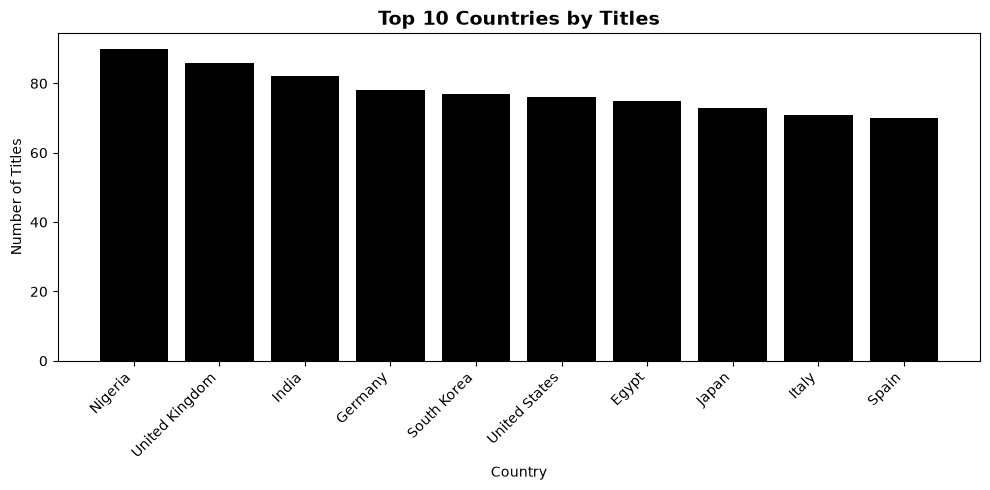

In [37]:
# Q28: Chart with title, labels, and custom color
plt.figure(figsize=(10, 5))
plt.bar(top_countries.index, top_countries.values, color='black')
plt.title("Top 10 Countries by Titles", fontsize=14, fontweight='bold')
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

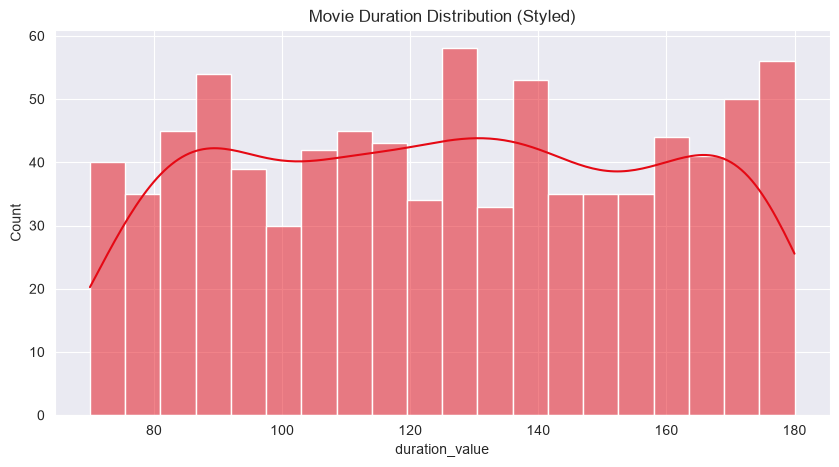

In [38]:
# Q29: Apply seaborn theme + save chart as PNG
sns.set_style("darkgrid")
plt.figure(figsize=(10, 5))
sns.histplot(movie_durations, bins=20, kde=True, color='#E50914')
plt.title("Movie Duration Distribution (Styled)")
plt.savefig("movie_duration_distribution.png", dpi=150)
plt.show()

In [39]:
# GENERAL ANALYSIS

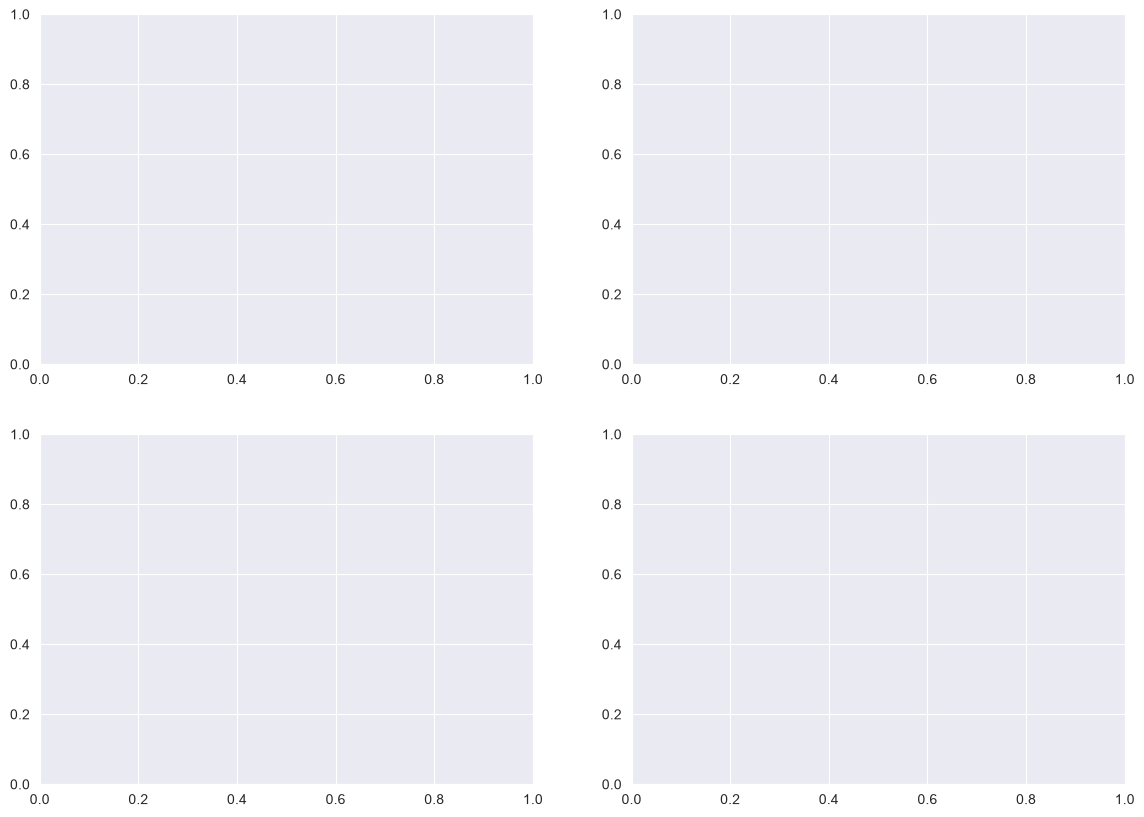

In [40]:
# Q30: 2x2 dashboard combining 4 charts
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

In [41]:
# Panel 1: Type split
axes[0, 0].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
               colors=['#E50914', '#221F1F'])
axes[0, 0].set_title("Movies vs TV Shows")

Text(0.5, 1.0, 'Movies vs TV Shows')

In [42]:
 # Panel 2: Titles by year
df['release_year'].value_counts().sort_index().plot(
    kind='line', marker='o', color='#E50914', ax=axes[0, 1])
axes[0, 1].set_title("Titles by Release Year")

Text(0.5, 1.0, 'Titles by Release Year')

In [43]:
# Panel 3: Top genres
top_genres.plot(kind='bar', color='#221F1F', ax=axes[1, 0])
axes[1, 0].set_title("Top 10 Genres")
axes[1, 0].tick_params(axis='x', rotation=45)

In [44]:
# Panel 4: Top countries
top_countries.plot(kind='barh', color='#E50914', ax=axes[1, 1])
axes[1, 1].set_title("Top 10 Countries")
axes[1, 1].invert_yaxis()
 
plt.tight_layout()
plt.savefig("netflix_dashboard.png", dpi=150)
plt.show()
 


<Figure size 640x480 with 0 Axes>

In [45]:
# Q31: Which year had the highest number of titles added to Netflix?
busiest_year = df['year_added'].value_counts().idxmax()
print("Busiest year for additions:", busiest_year)

Busiest year for additions: 2026.0


In [46]:
# Q32: What percentage of titles have a missing director?
missing_director_pct = (df['director'] == 'Not Specified').mean() * 100
print(f"Missing director: {missing_director_pct:.1f}%")

Missing director: 40.3%


In [47]:
# Q34: Find TV Shows with more than 5 seasons.
tv = df[df['type'] == 'TV Show']
long_shows = tv[tv['duration_value'] > 5][['title', 'duration_value']]
print(long_shows)

                title  duration_value
5           Dark Life             6.0
6      Bright Justice             9.0
7         Hidden Life             9.0
9     Real Chronicles             6.0
31        Hidden Life             7.0
...               ...             ...
1178       Real World             6.0
1187        Dark Life             9.0
1194      Wild Family             7.0
1196      Wild Hearts             7.0
1199   Modern Justice             6.0

[165 rows x 2 columns]


In [48]:
# Q35: Use np.where() to create a new column "is_recent"
# marking titles released in 2020 or later.
df['is_recent'] = np.where(df['release_year'] >= 2020, 'Recent', 'Older')
print(df['is_recent'].value_counts())

is_recent
Older     885
Recent    315
Name: count, dtype: int64
